<a href="https://colab.research.google.com/github/raghavrakesh20/Small-projects-practice./blob/main/Initial_work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The Geometry of Cultural Exchange: A Computational Analysis of Shi Xue.

In [1]:
# 1. Install the PDF reading library
!pip install PyMuPDF Pillow

import fitz  # PyMuPDF
import io
import os
from PIL import Image

# 2. Setup folders and file names
pdf_path = "視學.pdf"
output_folder = "shi_xue_images"
os.makedirs(output_folder, exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 66.2 MB/s eta 0:00:00


In [2]:
# Open the book
pdf_document = fitz.open(pdf_path)
image_count = 0

print(f"Opening {pdf_path}...")

Opening 視學.pdf...


In [3]:
# Loop through every page and extract images
for page_number in range(len(pdf_document)):
    page = pdf_document.load_page(page_number)
    image_list = page.get_images(full=True)

    for img_index, img in enumerate(image_list):
        xref = img[0]
        base_image = pdf_document.extract_image(xref)
        image_bytes = base_image["image"]
        image_ext = base_image["ext"]

        # Load it into a standard image format and save it
        image = Image.open(io.BytesIO(image_bytes))
        image_filename = f"page_{page_number+1}_img_{img_index+1}.{image_ext}"
        image_filepath = os.path.join(output_folder, image_filename)

        image.save(open(image_filepath, "wb"))
        image_count += 1

print(f"SUCCESS: Extracted {image_count} images into the '{output_folder}' folder.")

SUCCESS: Extracted 144 images into the 'shi_xue_images' folder.


In [ ]:
# Detecting the Geometry

In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

test_image = "shi_xue_images/page_10_img_1.png" # <--- UPDATE THIS LINE

# 2. Load the image
img = cv2.imread(test_image)

# --- THE SAFETY CHECK ---
if img is None:
    print(f"❌ ERROR: Could not find an image at: {test_image}")
    print("Please check the left sidebar to make sure the file name is spelled correctly!")
else:
    print("✅ Image loaded successfully!")
    # Convert to grayscale for the AI
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. Detect the "Wireframe" edges
edges = cv2.Canny(gray, 50, 150, apertureSize=3)

# 4. Hunt for perfect straight lines (Hough Transform Math)
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=80, minLineLength=50, maxLineGap=10)

# 5. Draw the detected lines in bright GREEN
line_img = img.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2) # 0, 255, 0 is Green

❌ ERROR: Could not find an image at: shi_xue_images/page_10_img_1.png
Please check the left sidebar to make sure the file name is spelled correctly!


NameError: name 'gray' is not defined

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


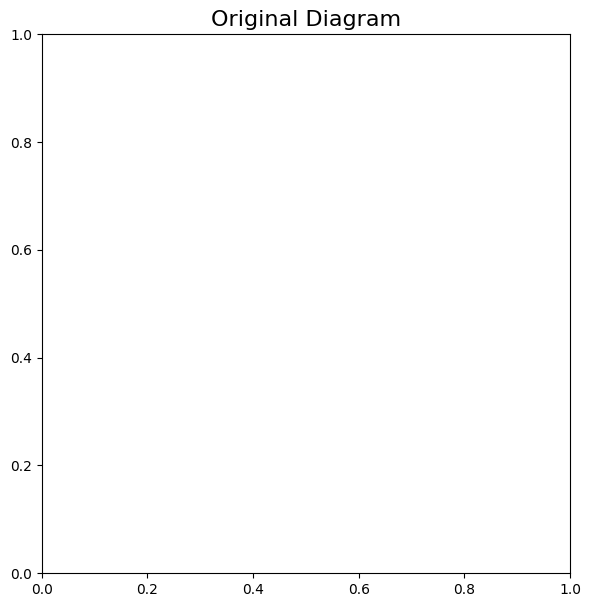

In [7]:
# 6. Display the comparison visually
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.title("Original Diagram", fontsize=16)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Computer Vision: Line Detection", fontsize=16)
plt.imshow(cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Finding the Vanishing Point (The Intersection)

✅ SUCCESS: Vanishing Point mathematically calculated at Coordinates: X=1384, Y=872


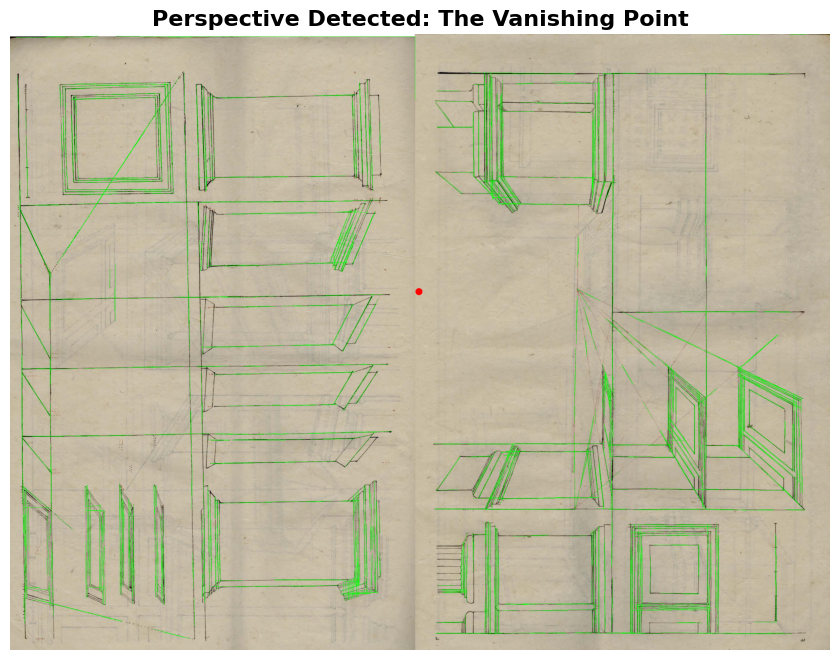

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

test_image = "/content/shi_xue_images/page_10_img_1.jpeg"
img = cv2.imread(test_image)

if img is None:
    print(f"❌ ERROR: Could not find an image at: {test_image}")
else:
    # 2. Re-run the edge and line detection from Step 2
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=80, minLineLength=50, maxLineGap=10)

    if lines is None:
        print("❌ ERROR: No straight lines detected in this image.")
    else:
        # 3. The Math: Build an equation for every single line
        A = []
        b = []
        for line in lines:
            x1, y1, x2, y2 = line[0]
            # Convert line segment into an algebraic formula (ax + by = c)
            a = y2 - y1
            b_coeff = x1 - x2
            c = a * x1 + b_coeff * y1
            A.append([a, b_coeff])
            b.append([c])

        A = np.array(A)
        b = np.array(b)

        # 4. The Magic: Find the single coordinate that intersects the most lines
        # This uses the "Least Squares" algorithm
        res = np.linalg.lstsq(A, b, rcond=None)
        vp_x, vp_y = int(res[0][0][0]), int(res[0][1][0])

        print(f"✅ SUCCESS: Vanishing Point mathematically calculated at Coordinates: X={vp_x}, Y={vp_y}")

        # 5. Draw the Results
        result_img = img.copy()

        # Draw the structure lines in Green
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(result_img, (x1, y1), (x2, y2), (0, 255, 0), 1)

        # Draw the Vanishing Point as a massive RED dot
        cv2.circle(result_img, (vp_x, vp_y), radius=12, color=(0, 0, 255), thickness=-1)

        # Display the final image
        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
        plt.title("Perspective Detected: The Vanishing Point", fontsize=16, fontweight='bold')
        plt.axis('off')
        plt.show()